# Detect Crop Diseases Using Aerial **Images**



In [2]:
!pip install -q torch torchvision
!pip install -q albumentations
!pip install -q timm
!pip install -q kaggle
!pip install -q scikit-learn matplotlib seaborn pandas
!pip install -q efficientnet_pytorch

In [3]:
import os
import random
import warnings
import time
from pathlib import Path

warnings.filterwarnings("ignore")
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import albumentations as A
from albumentations.pytorch import ToTensorV2

from efficientnet_pytorch import EfficientNet

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    recall_score)

In [4]:
torch.__version__

'2.10.0+cu128'

In [5]:
seed=42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

dvc = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [6]:
dvc

device(type='cuda')

## Dataset

In [7]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("killa92/crop-disease-image-classification-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'crop-disease-image-classification-dataset' dataset.
Path to dataset files: /kaggle/input/crop-disease-image-classification-dataset


In [8]:

for root, dirs, files in os.walk(path):
    depth = root.replace(path, '').count(os.sep)
    if depth > 2:
        dirs[:] = []
        continue
    indent = '   ' * depth
    print(f"{indent} {os.path.basename(root) or 'crop_disease_dataset'}/")
    for f in sorted(files)[:6]:
        print(f"{indent}    {f}")
    if len(files) > 6:
        print(len(files))


 crop-disease-image-classification-dataset/
    crop_disease_dataset/
       class_names.json
       meta_deta.csv
       images/
          157078263.jpg
          1574893536.jpg
          1575013487.jpg
          1576606254.jpg
          1579761476.jpg
          1581274070.jpg
17938


## Data Analysis

In [9]:
import json as json_lib
import pandas as pd
path="/kaggle/input/crop-disease-image-classification-dataset/crop_disease_dataset"

class_path = f"{path}/class_names.json"
csv_path    = f"{path}/meta_deta.csv"
img_path    = f"{path}/images"

with open(class_path, "r", encoding="utf-8") as f:
    raw_classes = json_lib.load(f)

if isinstance(raw_classes, dict):
    class_names = [raw_classes[str(i)] for i in range(len(raw_classes))]
elif isinstance(raw_classes, list):
    class_names = raw_classes
else:
    raise ValueError(type(raw_classes))

num_classes  = len(class_names)
CLASS_TO_IDX = {cls: i for i, cls in enumerate(class_names)}
IDX_TO_CLASS = {i: cls for i, cls in enumerate(class_names)}

print(f" {num_classes} sinif ")
for i, c in enumerate(class_names):
    print(c)

 5 sinif 
Cassava Bacterial Blight (CBB)
Cassava Brown Streak Disease (CBSD)
Cassava Green Mottle (CGM)
Cassava Mosaic Disease (CMD)
Healthy



##EDA: Class Balance

Siniflərin bərabər paylanıb-paylanmadığına baxaq.  
Əgər bir sinif çox az şəkilə malikdirsə, model onu öyrənə bilməz.

In [13]:
df = pd.read_csv(csv_path)
print(f"{len(df)} sətir, sütunlar: {list(df.columns)}")


21397 sətir, sütunlar: ['image_id', 'label']


In [14]:
df.head(2)

,image_id,label
0,1000015157.jpg,0
1,1000201771.jpg,3


In [15]:
df.dtypes

,0
image_id,object
label,int64


In [16]:
df.isnull().sum()

,0
image_id,0
label,0


In [17]:
df['label'].value_counts()

,count
label,
3,13158
4,2577
2,2386
1,2189
0,1087


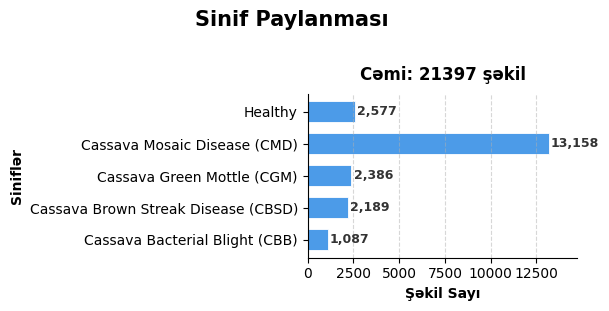

In [18]:
import matplotlib.pyplot as plt

total_counts_series = df['label'].value_counts()
total_counts = {IDX_TO_CLASS[i]: total_counts_series.get(i, 0) for i in range(num_classes)}
vals = [total_counts.get(c, 0) for c in class_names]

fig, ax = plt.subplots(figsize=(6, max(3, num_classes * 0.5)))

fig.suptitle("Sinif Paylanması ",fontsize=15, fontweight="bold", y=1.02)
bars = ax.barh(class_names, vals, color="#4C9BE8",edgecolor="white", linewidth=0.6, height=0.65)

ax.set_title(f"Cəmi: {sum(vals)} şəkil", fontweight="bold", fontsize=12, pad=10)
ax.set_xlabel("Şəkil Sayı", fontweight="bold")
ax.set_ylabel("Siniflər", fontweight="bold")

for bar, v in zip(bars, vals):
    if v > 0:
        ax.text(v + max(vals) * 0.01,
                bar.get_y() + bar.get_height() / 2,
                f"{v:,}", va="center", fontsize=9, fontweight="bold", color="#333333")

ax.set_xlim(0, max(vals) * 1.12 if vals else 1)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

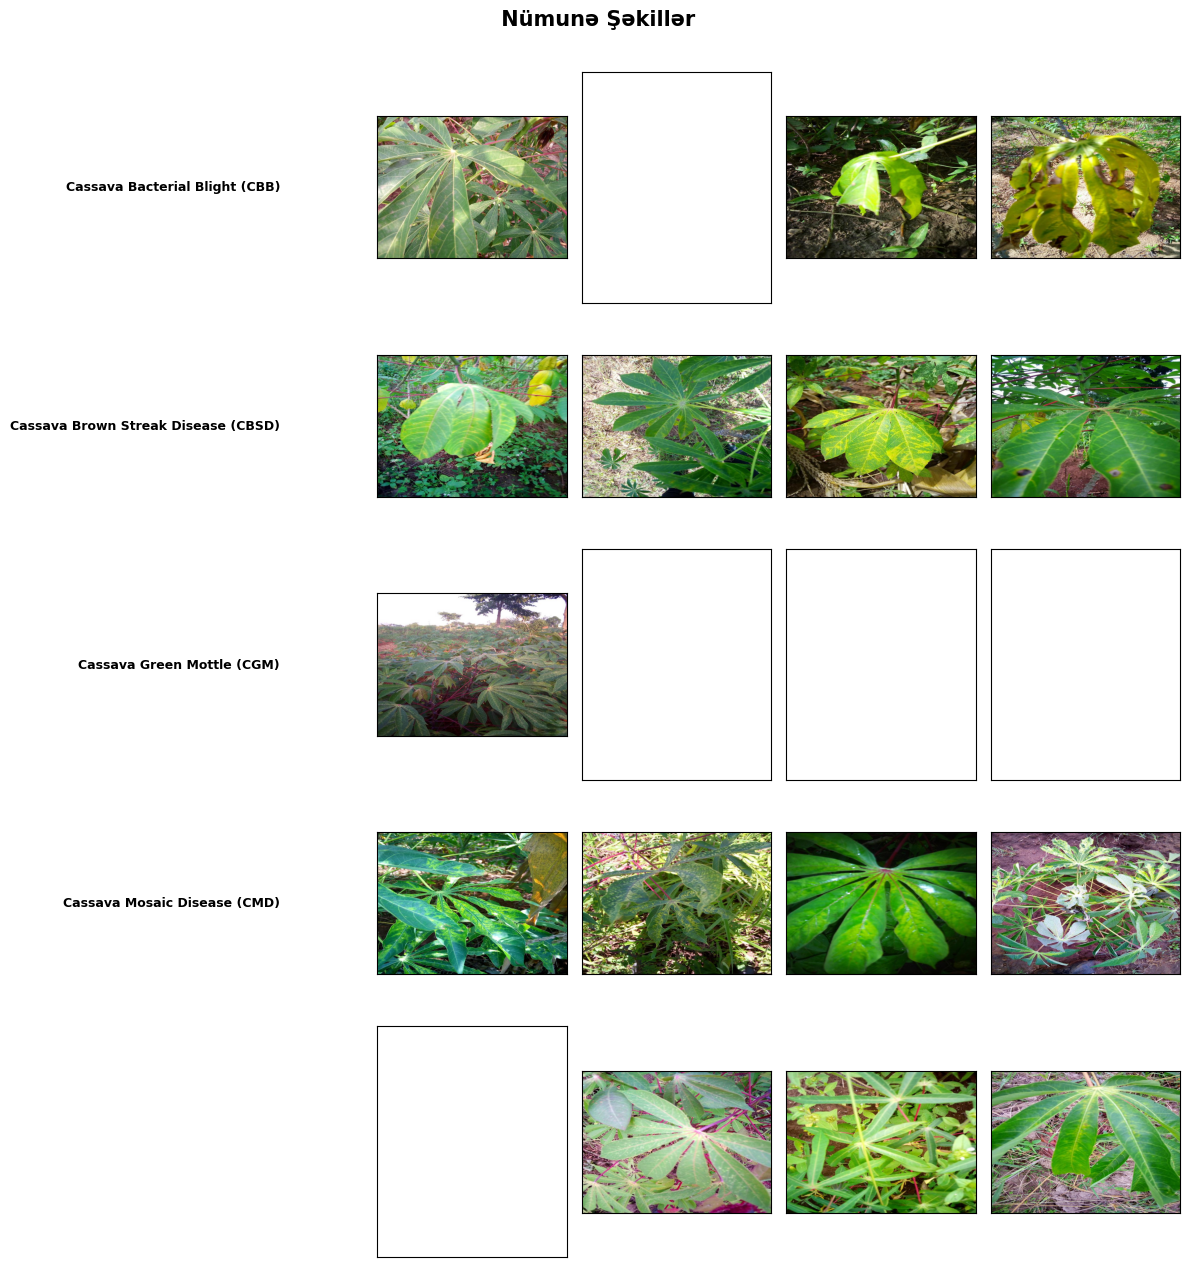

In [19]:
n = 4
fig, axes = plt.subplots(num_classes, n, figsize=(n * 3,num_classes * 2.5))
fig.suptitle(" Nümunə Şəkillər", fontsize=15, fontweight="bold", y=1.01)

for row, cls_name in enumerate(class_names):
    cls_idx = CLASS_TO_IDX[cls_name]
    subset = df[df['label'] == cls_idx]['image_id'].tolist()
    paths = [os.path.join(img_path, img_id) for img_id in random.sample(subset, min(n, len(subset)))]

    for col in range(n):
        ax = axes[row][col] if num_classes > 1 else axes[col]
        if col < len(paths):
            try:
                ax.imshow(Image.open(paths[col]).convert("RGB"))
                if col == 0:
                    ax.set_ylabel(cls_name, fontsize=9, fontweight="bold", rotation=0, labelpad=70, va="center", ha="right")
            except:
                ax.text(0.5, 0.5, " ", ha="center", va="center")
        else:
            ax.axis("off")
        ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.show()

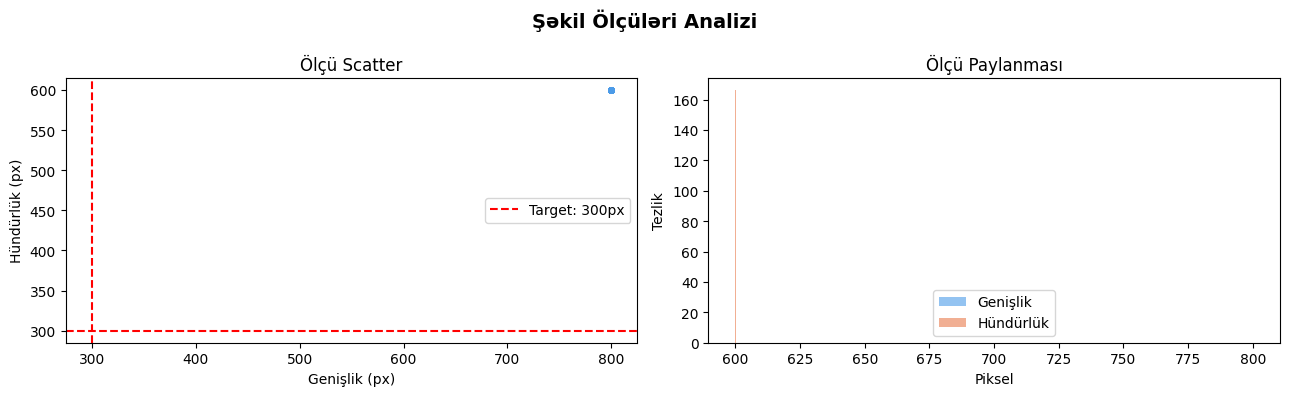


 Ölçü statistikası (166 şəkil üzrə):
   Genişlik : min=800, max=800, orta=800
   Hündürlük: min=600, max=600, orta=600


In [20]:
widths, heights = [], []
size  = 300       # EfficientNet-B3 üçün

sample_rows = df.sample(min(200, len(df)), random_state=42)
for _, row in sample_rows.iterrows():
    try:
        full_path = os.path.join(img_path, row['image_id'])
        with Image.open(full_path) as img:
            w, h = img.size
            widths.append(w)
            heights.append(h)
    except Exception:
        pass

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Şəkil Ölçüləri Analizi", fontsize=14, fontweight="bold")

axes[0].scatter(widths, heights, alpha=0.4, s=15, color="#4C9BE8")
axes[0].set_xlabel("Genişlik (px)")
axes[0].set_ylabel("Hündürlük (px)")
axes[0].set_title("Ölçü Scatter")
axes[0].axvline(size, color="red", linestyle="--", label=f"Target: {size}px")
axes[0].axhline(size, color="red", linestyle="--")
axes[0].legend()

axes[1].hist(widths,  bins=20, alpha=0.6, label="Genişlik", color="#4C9BE8")
axes[1].hist(heights, bins=20, alpha=0.6, label="Hündürlük", color="#E87B4C")
axes[1].set_xlabel("Piksel")
axes[1].set_ylabel("Tezlik")
axes[1].set_title("Ölçü Paylanması")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\n Ölçü statistikası ({len(widths)} şəkil üzrə):")
print(f"   Genişlik : min={min(widths)}, max={max(widths)}, orta={int(sum(widths)/len(widths))}")
print(f"   Hündürlük: min={min(heights)}, max={max(heights)}, orta={int(sum(heights)/len(heights))}")

## Train Test Data Split

In [21]:
# 70% train, 15% valid, 15% test — stratified (sinif balansını qoruyur)
from sklearn.model_selection import train_test_split
train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df['label'], random_state=42
)
valid_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df['label'], random_state=42
)

train_df = train_df.reset_index(drop=True)
valid_df = valid_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)


print(f"   Train : {len(train_df):>6} ")
print(f"   Valid : {len(valid_df):>6} ")
print(f"   Test  : {len(test_df):>6} ")


   Train :  14977 
   Valid :   3210 
   Test  :   3210 


In [22]:
"""DataFrame-dən hər sinif üçün şəkil sayını hesablayır."""
extensions = {".jpg", ".jpeg", ".png"}

def count_per_class_df(df):

    counts = df['label'].value_counts().sort_index()
    return {IDX_TO_CLASS[i]: counts.get(i, 0) for i in range(num_classes)}

train_counts = count_per_class_df(train_df)
valid_counts = count_per_class_df(valid_df)
test_counts  = count_per_class_df(test_df)



In [23]:
print(f"{'Sinif':<40} {'Train':>7} {'Valid':>7} {'Test':>7} {'Cəmi':>7}")
t_total = v_total = ts_total = 0
for cls in class_names:
    tr = train_counts.get(cls, 0)
    vl = valid_counts.get(cls, 0)
    ts = test_counts.get(cls, 0)
    t_total  += tr
    v_total  += vl
    ts_total += ts
    print(f"{cls:<40} {tr:>7} {vl:>7} {ts:>7} {tr+vl+ts:>7}")


Sinif                                      Train   Valid    Test    Cəmi
Cassava Bacterial Blight (CBB)               761     163     163    1087
Cassava Brown Streak Disease (CBSD)         1532     328     329    2189
Cassava Green Mottle (CGM)                  1670     358     358    2386
Cassava Mosaic Disease (CMD)                9210    1974    1974   13158
Healthy                                     1804     387     386    2577


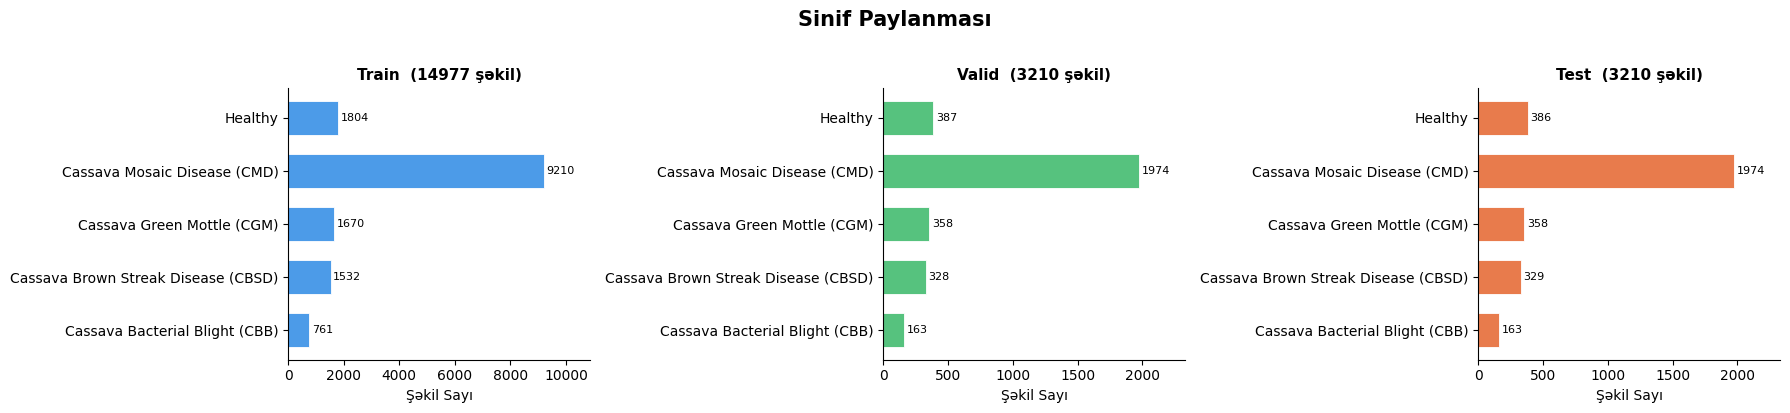

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, max(4, num_classes * 0.7)))
fig.suptitle("Sinif Paylanması",fontsize=15, fontweight="bold", y=1.02)

splits_info = [
    ("Train",  train_counts, "#4C9BE8"),
    ("Valid",  valid_counts, "#56C27E"),
    ("Test",   test_counts,  "#E87B4C"),]

for ax, (split_name, counts, color) in zip(axes, splits_info):
    vals = [counts.get(c, 0) for c in class_names]
    bars = ax.barh(class_names, vals, color=color,
                   edgecolor="white", linewidth=0.6, height=0.65)
    ax.set_title(f"{split_name}  ({sum(vals)} şəkil)",
                 fontweight="bold", fontsize=11)
    ax.set_xlabel("Şəkil Sayı")
    for bar, v in zip(bars, vals):
        if v > 0:
            ax.text(v + max(vals)*0.01,
                    bar.get_y() + bar.get_height() / 2,
                    str(v), va="center", fontsize=8)
    ax.set_xlim(0, max(vals) * 1.18 if vals else 1)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

In [25]:
#Balans Analizi
max_cls = max(train_counts, key=train_counts.get)
min_cls = min(train_counts, key=train_counts.get)
max_n   = train_counts[max_cls]
min_n   = max(train_counts[min_cls], 1)
imbalance_ratio = max_n / min_n

print(f"   Max : {max_cls}  {max_n} şəkil")
print(f"   Min   : {min_cls}  {train_counts[min_cls]} şəkil")
print(f"   Nisbət  : {imbalance_ratio:.1f}x")

   Max : Cassava Mosaic Disease (CMD)  9210 şəkil
   Min   : Cassava Bacterial Blight (CBB)  761 şəkil
   Nisbət  : 12.1x


Dataset ciddi şəkildə balanslaşdırılmamışdır!!!

##Data Augmentation

Drone şəkilləri müxtəlif bucaq, işıq, yüksəklik şəraitlərindən çəkilir.  
Augmentation mövcud şəkilləri süni olaraq dəyişdirib modeli daha güclü edir.

In [26]:
#Train üçün augmentation
train_transform = A.Compose([
    A.Resize(size, size),

    A.HorizontalFlip(p=0.5),  # Drone müxtəlif istiqamətdən uça bilər
    A.VerticalFlip(p=0.3),
    A.Rotate(limit=25, p=0.5),

    A.RandomResizedCrop(      #Kəsmə crop
        size=(size, size),
        scale=(0.75, 1.0), p=0.4),

    A.RandomBrightnessContrast( #İşıqlanma
        brightness_limit=0.25,
        contrast_limit=0.25, p=0.5),
    A.HueSaturationValue(
        hue_shift_limit=15,
        sat_shift_limit=25,
        val_shift_limit=20, p=0.4),

    A.GaussNoise(var_limit=(5.0, 25.0), p=0.25), #Küy — drone sensor küyü simulyasiya
    A.GaussianBlur(blur_limit=(3, 5), p=0.15),

    #Normallaşdırma ve Tensor çevrilməsi
    A.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
    ToTensorV2() ])

In [27]:
#Validation + Test üçün minimal transform
#ölçü standartlaşdırması + normallaşdırma
#Augmentation yoxdur real nəticəni görürük
eval_transform = A.Compose([
    A.Resize(size, size),
    A.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
    ToTensorV2()])

In [28]:
len(train_transform.transforms)

11

In [29]:
len(eval_transform.transforms)

3

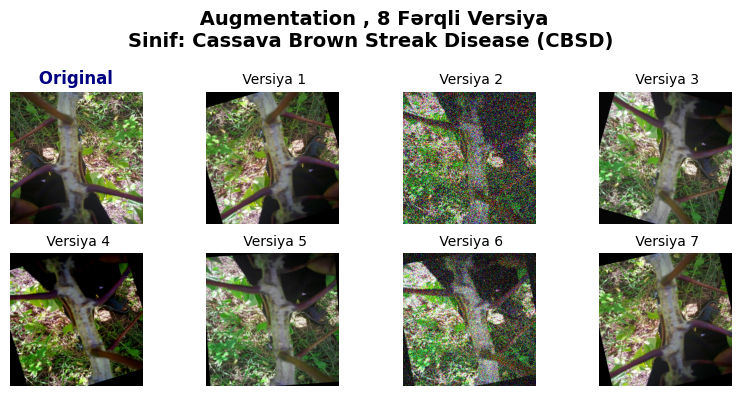

In [30]:

sample_rows = df.sample(min(20, len(df)), random_state=42)
for _, row in sample_rows.iterrows():
    try:
        full_path = os.path.join(img_path, row['image_id'])
        sample_arr = np.array(Image.open(full_path).convert("RGB"))
        current_label = row['label']
    except Exception:
        pass

aug_visual = A.Compose([
    A.Resize(size, size),
    A.HorizontalFlip(p=0.6),
    A.VerticalFlip(p=0.4),
    A.Rotate(limit=25, p=0.8),
    A.RandomBrightnessContrast(p=0.7),
    A.HueSaturationValue(p=0.5),
    A.GaussNoise(p=0.3),])

fig, axes = plt.subplots(2, 4, figsize= (8,4))
fig.suptitle(f" Augmentation , 8 Fərqli Versiya\nSinif: {class_names[current_label]}", fontsize=14, fontweight="bold")
flat_axes = axes.flatten()

orig_resized = A.Resize(size, size)(image=sample_arr)["image"]
flat_axes[0].imshow(orig_resized)
flat_axes[0].set_title(" Original ", fontweight="bold", color="navy")
flat_axes[0].axis("off")

#fərqli variantlar
for idx in range(1, 8):
    aug_img = aug_visual(image=sample_arr)["image"]
    flat_axes[idx].imshow(aug_img)
    flat_axes[idx].set_title(f" Versiya {idx}", fontsize=10)
    flat_axes[idx].axis("off")

plt.tight_layout()
plt.show()

## Custom Dataset and Data Loader

In [31]:
class CropDiseaseDataset(Dataset):
    """
    CSV-əsaslı PyTorch Dataset.

    df sütunları:
        image_id  — fayl adı (məs: 1000015157.jpg)
        label     — sinif indeksi (0, 1, 2, ...)

    img_dir — şəkillərin yerləşdiyi qovluq
    """

    def __init__(self, df, img_dir, class_names, transform=None):
        self.df          = df.reset_index(drop=True)
        self.img_dir     = img_dir
        self.class_names = class_names
        self.transform   = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, str(row['image_id']))
        label    = int(row['label'])

        image = np.array(Image.open(img_path).convert("RGB"))

        if self.transform:
            image = self.transform(image=image)["image"]

        return image, label

In [32]:
# Mövcud faylları yoxlayib əksikləri sildim
existing_files = set(os.listdir(img_path))

train_df = train_df[train_df['image_id'].astype(str).isin(existing_files)].reset_index(drop=True)
valid_df  = valid_df[valid_df['image_id'].astype(str).isin(existing_files)].reset_index(drop=True)
test_df   = test_df[test_df['image_id'].astype(str).isin(existing_files)].reset_index(drop=True)

print(f"Train: {len(train_df)}, Valid: {len(valid_df)}, Test: {len(test_df)}")

Train: 12528, Valid: 2732, Test: 2678


In [33]:
#Dataset obyektləri
train_dataset = CropDiseaseDataset(train_df, img_path, class_names, transform=train_transform)
valid_dataset = CropDiseaseDataset(valid_df, img_path, class_names, transform=eval_transform)
test_dataset  = CropDiseaseDataset(test_df,  img_path, class_names, transform=eval_transform)

print(f" Train : {len(train_dataset)} şəkil")
print(f" Valid : {len(valid_dataset):} şəkil")
print(f" Test  : {len(test_dataset):} şəkil")


 Train : 12528 şəkil
 Valid : 2732 şəkil
 Test  : 2678 şəkil


## Balancing

In [34]:
# WeightedRandomSampler
import torch.utils.data as data
from torch.utils.data.sampler import WeightedRandomSampler

class_counts = train_df['label'].value_counts().sort_index().values
class_weights = 1.0 / class_counts
sample_weights = [class_weights[label] for label in train_df['label']]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True)

In [36]:
batch= 16

train_loader = DataLoader(
    train_dataset, batch_size=batch,
    sampler=sampler,
    num_workers=2, pin_memory=True
)

valid_loader = DataLoader(
    valid_dataset, batch_size=batch,
    shuffle=False,
    num_workers=2, pin_memory=True
)

test_loader = DataLoader(
    test_dataset,  batch_size=batch,
    shuffle=False,
    num_workers=2, pin_memory=True)

In [37]:
#Batch yoxlanisi ve balans testi
sample_imgs, sample_lbls = next(iter(train_loader))
print(f"Şəkil tensor forması  : {list(sample_imgs.shape)}")
print(f"Etiket tensor forması : {list(sample_lbls.shape)}")
print(f"Unikal etiketlər      : {sorted(sample_lbls.unique().tolist())}")

#Modelin ilk oxudugu 32 şəklin sinif paylanmasını cap edirik balanslı olmalıdır
print(f"Oversampled :\n{pd.Series(sample_lbls.numpy()).value_counts().sort_index()}")

Şəkil tensor forması  : [16, 3, 300, 300]
Etiket tensor forması : [16]
Unikal etiketlər      : [0, 1, 2, 3, 4]
Oversampled :
0    4
1    4
2    4
3    2
4    2
Name: count, dtype: int64


##EfficientNet-B3 Model Set

**Transfer Learning:** ImageNet-də (1.2M şəkil) öyrədilmiş bir modelin  
ağırlıqlarını götürüb öz problemimizə uyğunlaşdırırıq.  
Bu xüsusilə az data olduqda çox effektivdir.

In [38]:

model = EfficientNet.from_pretrained("efficientnet-b3")

#Son fully-connected qatı dəyişdiririk
in_features = model._fc.in_features   # son qatın giriş neyron sayı
model._fc   = nn.Linear(in_features, num_classes)

model = model.to(dvc)

#Parametr statistikası
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters()
                       if p.requires_grad)


Downloading: "https://github.com/lukemelas/EfficientNet-PyTorch/releases/download/1.0/efficientnet-b3-5fb5a3c3.pth" to /root/.cache/torch/hub/checkpoints/efficientnet-b3-5fb5a3c3.pth


100%|██████████| 47.1M/47.1M [00:00<00:00, 120MB/s]


Loaded pretrained weights for efficientnet-b3


In [39]:
#Son qat giriş: neyron
in_features

1536

In [40]:
#Son qat çıxış: sinif
num_classes

5

In [41]:
total_params

10703917

In [42]:
trainable_params

10703917

In [43]:
#Loss funksiyası, Optimizer, Scheduler
epochs=2
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=3e-4, weight_decay=1e-5)

#CosineAnnealingLR  öyrənmə sürətini cosine cədvəlinə görə azaldır
#StepLRdən daha hamar azalma verir
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=epochs, eta_min=1e-6)

##Modelin Trainig

Training loop 3 addımdan ibarətdir:
1. **Forward pass** — Şəkil  Model  Proqnoz
2. **Loss hesablanması** — Proqnoz nə qədər yanlışdır?
3. **Backward pass** — Yanlışlığa görə ağırlıqları yenilə

In [45]:
def train_one_epoch(model, loader, criterion, optimizer, device):

    model.train()

    total_loss    = 0.0
    correct       = 0
    total         = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)


        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds       = outputs.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += images.size(0)

    return total_loss / total, correct / total


In [46]:
def evaluate_model(model, loader, criterion, device):

    #Modeli validation/test setində qiymətləndirir
    model.eval()

    total_loss = 0.0
    correct    = 0
    total      = 0

    with torch.no_grad():
        for images, labels in loader:
            images  = images.to(device)
            labels  = labels.to(device)
            outputs = model(images)
            loss    = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            preds       = outputs.argmax(dim=1)
            correct    += (preds == labels).sum().item()
            total      += images.size(0)

    return total_loss / total, correct / total


In [47]:
best_path = "best_efficientnet_b3.pth"
history = {"train_loss": [], "train_acc": [], "valid_loss": [], "valid_acc": []}
best_valid_acc = 0.0
epochs_no_improve = 0
patience = 5


for epoch in range(1, epochs + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, dvc)
    vl_loss, vl_acc = evaluate_model(model, valid_loader, criterion, dvc)
    scheduler.step()

    for k, v in zip(history, [tr_loss, tr_acc, vl_loss, vl_acc]):
        history[k].append(v)

    marker = ""
    if vl_acc > best_valid_acc:
        best_valid_acc = vl_acc
        torch.save(model.state_dict(), best_path)
        epochs_no_improve = 0
        marker = "-"
    else:
        epochs_no_improve += 1

    print(f"Epoch {epoch:02d}   Train {tr_acc*100:.1f}%   Val {vl_acc*100:.1f}%{marker}")

    if epochs_no_improve >= patience:
        print(f"Early stopping ({patience} epoch)")
        break

print(f"Best Val Acc: {best_valid_acc*100:.2f}%")

Epoch 01   Train 62.4%   Val 78.5%-
Epoch 02   Train 72.2%   Val 82.1%-
Best Val Acc: 82.14%


In [ ]:
'''import gc
torch.cuda.empty_cache()
gc.collect()'''

##Results Visualization

Öyrənmə əyrisi — modelin necə inkişaf etdiyini görürük.

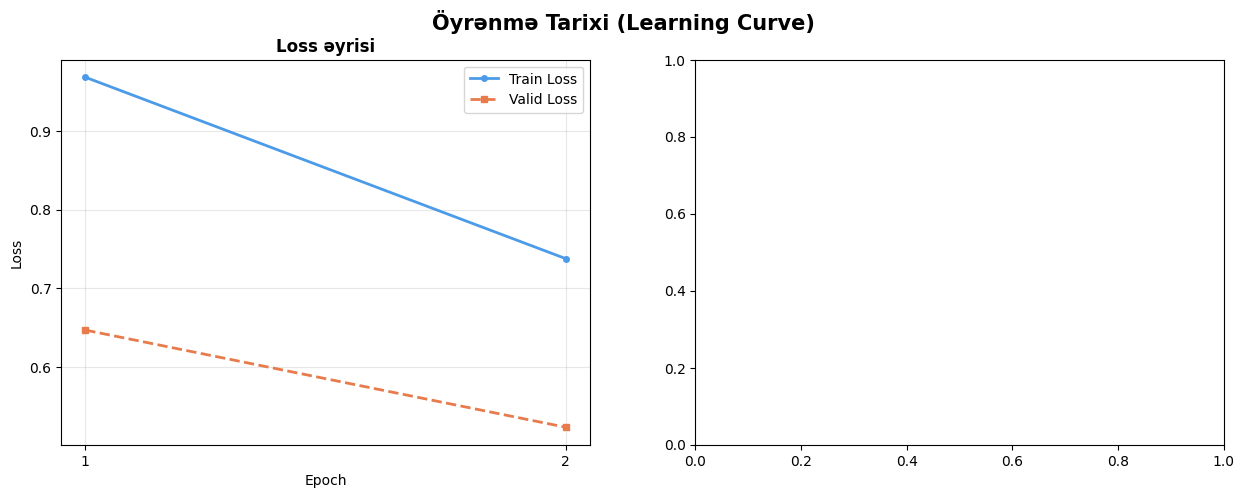

In [48]:
#Learning Curve: Loss + Accuracy
actual_epochs = len(history["train_loss"])
ep_range = range(1, actual_epochs + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Öyrənmə Tarixi (Learning Curve)",fontsize=15, fontweight="bold")

ax1.plot(ep_range, history["train_loss"],"o-", color="#4C9BE8", label="Train Loss", linewidth=2, ms=4)
ax1.plot(ep_range, history["valid_loss"],"s--", color="#E87B4C", label="Valid Loss", linewidth=2, ms=4)

ax1.set_title("Loss əyrisi", fontweight="bold")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.grid(alpha=0.3)
ax1.set_xticks(ep_range)


In [49]:
last_train = history["train_loss"][-1]
last_valid = history["valid_loss"][-1]
if last_valid > last_train * 1.3:
    ax1.text(0.5, 0.95, "Overfitting!",
             transform=ax1.transAxes, ha="center", va="top",
             color="red", fontweight="bold")

In [54]:
#Test setindən bütün proqnozları toplayaq
all_preds  = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images  = images.to(dvc)
        outputs = model(images)
        preds   = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

##Qiymətləndirmə

Ən yaxşı modeli yükləyib **test setində** qiymətləndiririk.  
Per-class Recall hər xəstəliyin nə qədər düzgün aşkar edildiyini göstərir.

In [51]:
best_epoch = history["valid_acc"].index(max(history["valid_acc"])) + 1
print(f"Summary")
print(f"Best Valid Acc : {max(history['valid_acc'])*100:.2f}% "f"(Epoch {best_epoch})")
print(f"Son Train Loss : {history['train_loss'][-1]:.4f}")
print(f"Son Valid Loss : {history['valid_loss'][-1]:.4f}")

Summary
Best Valid Acc : 82.14% (Epoch 2)
Son Train Loss : 0.7376
Son Valid Loss : 0.5235


In [55]:
test_acc = accuracy_score(all_labels, all_preds)
recalls  = recall_score(all_labels, all_preds, average=None,
                        zero_division=0)

print(f" Accuracy: {test_acc*100:.2f}%")

print(f"\n{'Sinif':<35} {'Recall':>9}")
print("-" * 46)
for cls_name, rec in zip(class_names, recalls):
    icon = "asagi" if rec >= 0.80 else "orta" if rec >= 0.60 else "yuksek"
    print(f"{cls_name:<35} {rec*100:>8.2f}%  {icon}")
print("-" * 46)
print(f"{'Orta Recall':<35} {recalls.mean()*100:>8.2f}%")

 Accuracy: 83.79%

Sinif                                  Recall
----------------------------------------------
Cassava Bacterial Blight (CBB)         57.97%  yuksek
Cassava Brown Streak Disease (CBSD)    73.91%  orta
Cassava Green Mottle (CGM)             84.05%  asagi
Cassava Mosaic Disease (CMD)           89.63%  asagi
Healthy                                73.37%  orta
----------------------------------------------
Orta Recall                            75.79%


In [56]:
#Tam Classification Report

print(classification_report(
    all_labels, all_preds,
    target_names=class_names,
    digits=4
))

                                     precision    recall  f1-score   support

     Cassava Bacterial Blight (CBB)     0.6250    0.5797    0.6015       138
Cassava Brown Streak Disease (CBSD)     0.7391    0.7391    0.7391       276
         Cassava Green Mottle (CGM)     0.7087    0.8405    0.7690       301
       Cassava Mosaic Disease (CMD)     0.9729    0.8963    0.9330      1640
                            Healthy     0.5837    0.7337    0.6502       323

                           accuracy                         0.8379      2678
                          macro avg     0.7259    0.7579    0.7386      2678
                       weighted avg     0.8542    0.8379    0.8434      2678



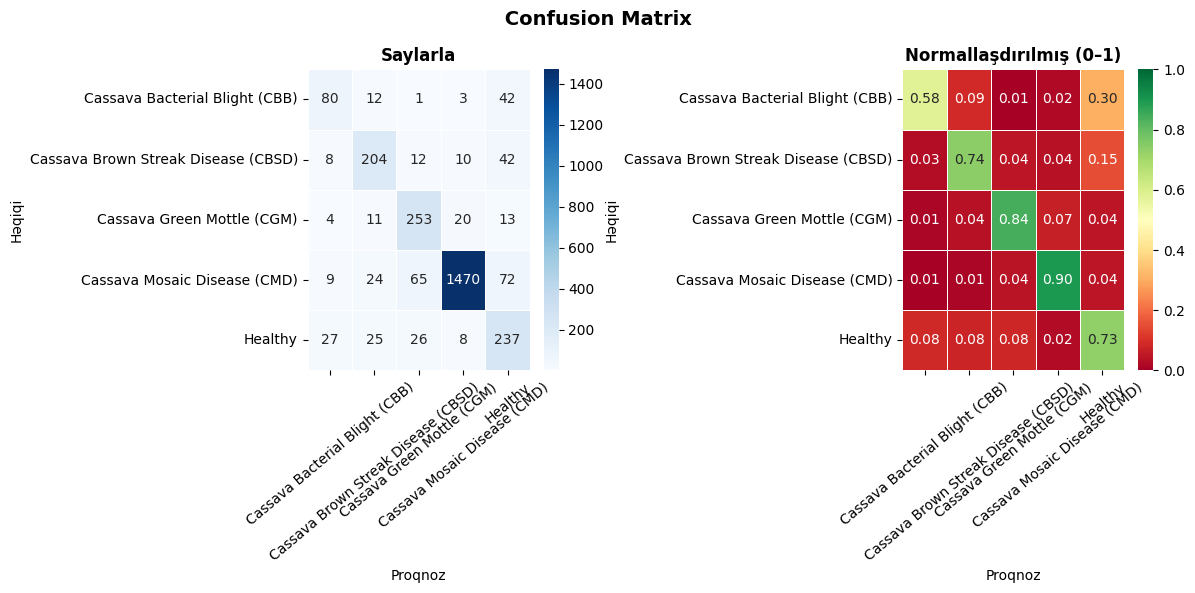

In [57]:
#Confusion Matrix
cm      = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

fig_h = max(6, num_classes * 0.7)
fig_w = fig_h * 2
fig, axes = plt.subplots(1, 2, figsize=(fig_w, fig_h))
fig.suptitle(" Confusion Matrix", fontsize=14, fontweight="bold")

# Saylarla
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names,
            ax=axes[0], linewidths=0.5)
axes[0].set_title("Saylarla", fontweight="bold")
axes[0].set_xlabel("Proqnoz")
axes[0].set_ylabel("Həqiqi")
axes[0].tick_params(axis="x", rotation=40)

# Normallaşdırılmış (0-1)
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="RdYlGn",
            xticklabels=class_names, yticklabels=class_names,
            ax=axes[1], linewidths=0.5, vmin=0, vmax=1)
axes[1].set_title("Normallaşdırılmış (0–1)", fontweight="bold")
axes[1].set_xlabel("Proqnoz")
axes[1].set_ylabel("Həqiqi")
axes[1].tick_params(axis="x", rotation=40)

plt.tight_layout()
plt.show()
